# NYC 311 Service Requests: Resolution Time Analysis
## First 3 months of COVID-19 in New York City

**Objective**: Analyze resolution times for high-volume complaint types during early COVID to understand how the pandemic affected city service responses.

**Data Source:** NYC 311 Service Requests via Bigquery public dataset (~500k records, first 3 months from first confirmed case of COVID-19 in NYC)

**Key Question:** Which complaint types took the longest to resolve, and what does that reveal about city operations under crisis?

### Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Show plots inline in the notebook
%matplotlib inline
# Set default chart style
sns.set_style("whitegrid")

print("Setup Complete")
print(f"pandas version: {pd.__version__}")

Setup Complete
pandas version: 2.2.2


### Import SQL data from BigQuery & run cleanup

In [2]:
from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery

project_id = "nyc311-project-roguelafayette"
client = bigquery.Client(project=project_id)

query = """
SELECT
  unique_key,
  created_date,
  closed_date,
  complaint_type,
  descriptor,
  borough,
  status,
  DATE_DIFF(closed_date, created_date, HOUR) AS resolution_hours
FROM `bigquery-public-data.new_york_311.311_service_requests`
WHERE DATE(created_date) BETWEEN DATE('2020-03-01') AND DATE('2020-06-01')
  AND borough IS NOT NULL
  AND closed_date IS NOT NULL
ORDER BY created_date ASC
LIMIT 500000;
"""

df = client.query(query).to_dataframe()
df.head()

,unique_key,created_date,closed_date,complaint_type,descriptor,borough,status,resolution_hours
0,45728413,2020-03-01 00:00:00+00:00,2020-03-02 00:00:01+00:00,Food Poisoning,1 or 2,MANHATTAN,Closed,24
1,45731136,2020-03-01 00:00:00+00:00,2020-03-09 00:00:01+00:00,Food Poisoning,1 or 2,QUEENS,Closed,192
2,45731855,2020-03-01 00:00:00+00:00,2020-03-02 10:19:39+00:00,Food Poisoning,1 or 2,BRONX,Closed,34
3,45730477,2020-03-01 00:00:00+00:00,2020-03-02 00:00:01+00:00,Food Poisoning,1 or 2,BRONX,Closed,24
4,45727718,2020-03-01 00:00:00+00:00,2020-03-02 10:37:56+00:00,Food Poisoning,1 or 2,BRONX,Closed,34


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 489972 entries, 0 to 489971
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype              
---  ------            --------------   -----              
 0   unique_key        489972 non-null  Int64              
 1   created_date      489972 non-null  datetime64[us, UTC]
 2   closed_date       489972 non-null  datetime64[us, UTC]
 3   complaint_type    489972 non-null  object             
 4   descriptor        489972 non-null  object             
 5   borough           489972 non-null  object             
 6   status            489972 non-null  object             
 7   resolution_hours  489972 non-null  Int64              
dtypes: Int64(2), datetime64[us, UTC](2), object(4)
memory usage: 30.8+ MB


In [4]:
# Before adjusting, noting original size
print(f"Before Cleanup: {len(df)} rows")

Before Cleanup: 489972 rows


In [5]:
# Drop rows missing critical fields in case any were missed in SQL
df_clean = df.dropna(subset=['borough', 'complaint_type'])

print(f"After Cleanup: {len(df_clean)} rows")
print(f"{len(df) - len(df_clean)} rows dropped")

After Cleanup: 489972 rows
0 rows dropped


In [6]:
# Are there any duplicate unique_keys?
duplicates = df_clean['unique_key'].duplicated().sum()
print (f"Duplicate Records: {duplicates}")

Duplicate Records: 0


In [7]:
# Basic Stats
df_clean['resolution_hours'].describe()

,resolution_hours
count,489972.0
mean,224.097138
std,1808.036694
min,-1053462.0
25%,0.0
50%,1.0
75%,37.0
max,14635.0


In [8]:
# Assess Negatives
negative_hours = (df_clean['resolution_hours'] < 0).sum()
print(f"Negative Resolution Times: {negative_hours}")

Negative Resolution Times: 4613


In [9]:
# Assess MAX - data >1 year
extreme = (df_clean['resolution_hours'] > 8760).sum()
print(f"Data >1 year: {extreme}")

Data >1 year: 1922


In [10]:
# Drop Outliers (negative times and data >1 year)
df_clean = df_clean[df_clean['resolution_hours'] >= 0]
df_clean = df_clean[df_clean['resolution_hours'] <= 8760]

print(f"After Outlier Cleanup: {len(df_clean)} rows")
print(f"{len(df) - len(df_clean)} rows dropped")

After Outlier Cleanup: 483437 rows
6535 rows dropped


### Saved cleaned data to Cloud Drive

In [11]:
# Save Cleaned version of data
df_clean.to_csv('nyc_311_covid_first_3_months_cleaned.csv', index=False)
print(f"Saved {len(df_clean)} clean rows")

Saved 483437 clean rows


In [12]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
df_clean.to_csv('/content/drive/MyDrive/nyc_311_covid_first_3_months_cleaned.csv', index=False)

print(f"Saved {len(df_clean)} rows to Google Drive")

Saved 483437 rows to Google Drive


## Exploratory Data Analysis (EDA)

### What are the top Complaint Types

In [14]:
# Count of each complaint type
top_complaints = df_clean['complaint_type'].value_counts().head(15)
print(top_complaints)

complaint_type
Noise - Residential              92074
Non-Emergency Police Matter      57149
HEAT/HOT WATER                   35577
Illegal Parking                  31890
Noise - Street/Sidewalk          31254
Consumer Complaint               20576
Blocked Driveway                 16455
Noise - Vehicle                  14401
Street Condition                 12259
Noise                            11222
UNSANITARY CONDITION             10410
PLUMBING                          7250
Water System                      7241
General Construction/Plumbing     6967
Street Light Condition            6499
Name: count, dtype: int64


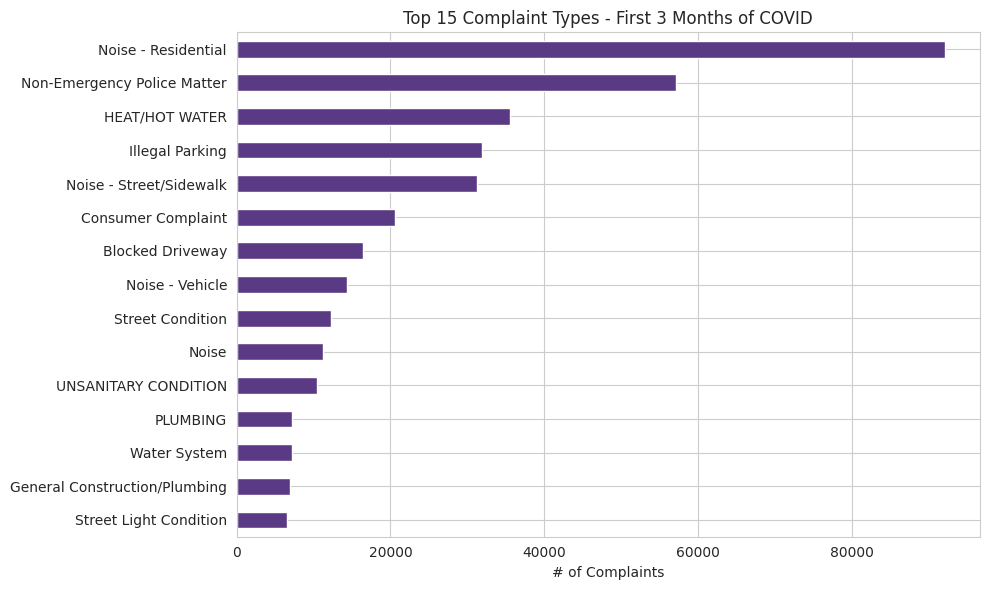

In [15]:
# Visualized
plt.figure(figsize=(10, 6))
top_complaints = df_clean['complaint_type'].value_counts().head(15).sort_values(ascending=True)
top_complaints.plot(kind='barh', color = '#5B3A85')
plt.title('Top 15 Complaint Types - First 3 Months of COVID')
plt.ylabel("")
plt.xlabel('# of Complaints')
plt.tight_layout()
plt.show()

**Finding:** Noise complaints (unsurprisingly) vastly outnumber the other complaints in NYC (almost twice as high as the next highest total). Possibly exacerbated by the increase of citizens staying indoors closer to each other and with more quiet around outside to contrast loud noises.

### Analysis: How are complaints distributed across boroughs?

In [16]:
# Count by borough - "Unspecified" boroughs not included
borough_counts = df_clean['borough'].value_counts().head(5)
print(borough_counts)

borough
BROOKLYN         141333
BRONX            109959
QUEENS           105685
MANHATTAN        103382
STATEN ISLAND     20128
Name: count, dtype: int64


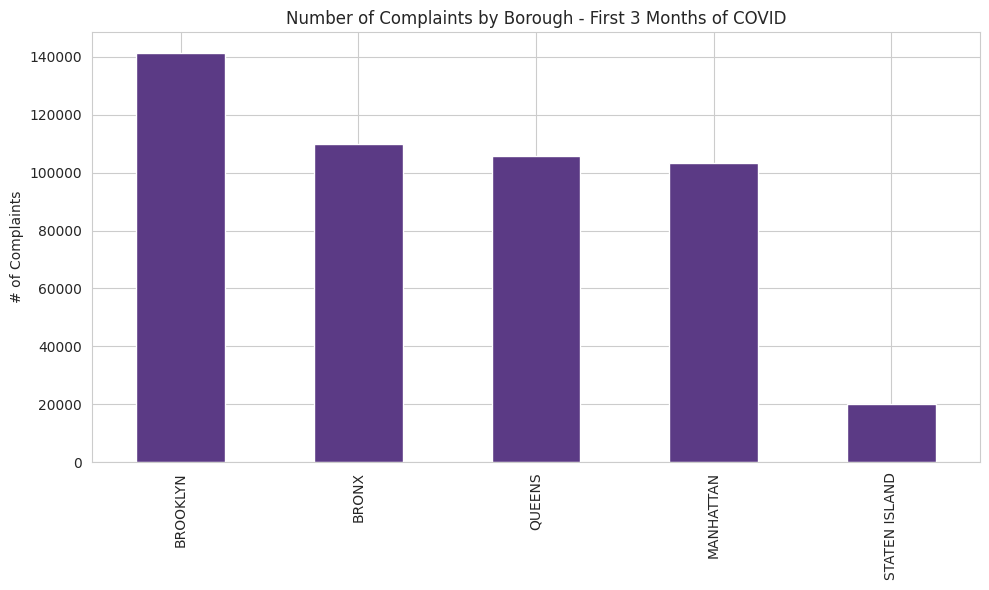

In [17]:
# Visualize
plt.figure(figsize=(10, 6))
borough_counts.plot(kind='bar', color = '#5B3A85')
plt.title('Number of Complaints by Borough - First 3 Months of COVID')
plt.xlabel('')
plt.ylabel('# of Complaints')
plt.tight_layout()
plt.show()

**Finding:** Brooklyn leads in complaints due to its larger population size. Additionally Staten Island's lower population tracks for lower volume requests.

### Analysis: Whats the distribution of resolution times?

In [18]:
# Basic Stats
print(df_clean['resolution_hours'].describe())

count      483437.0
mean     186.533255
std      727.062264
min             0.0
25%             0.0
50%             2.0
75%            36.0
max          8758.0
Name: resolution_hours, dtype: Float64


In [19]:
# Distribution (in days for readability)
df_clean['resolution_days'] = df_clean['resolution_hours'] / 24

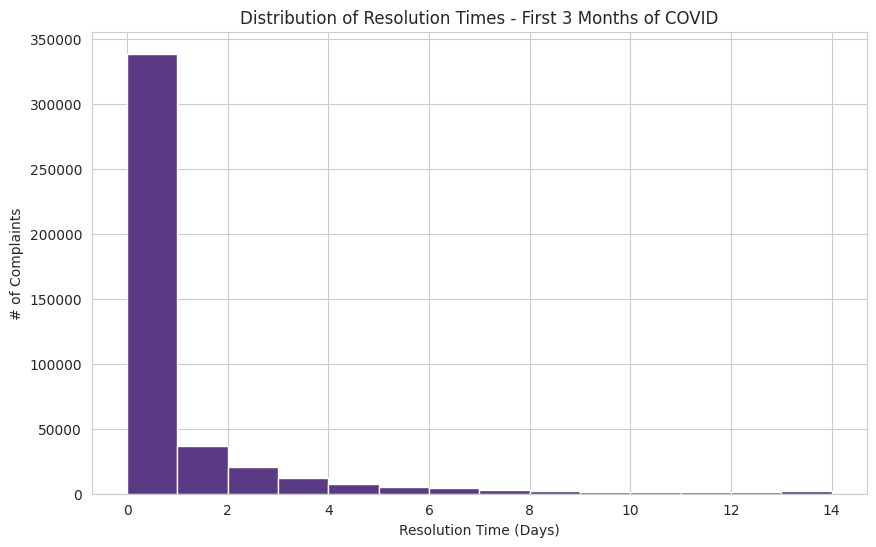

In [20]:
#Histogram, capped at 2 Weeks for readability
plt.figure(figsize=(10, 6))
df_clean[df_clean['resolution_days']<=14]['resolution_days'].plot(kind='hist', bins=14, color = '#5B3A85')
plt.title('Distribution of Resolution Times - First 3 Months of COVID')
plt.xlabel('Resolution Time (Days)')
plt.ylabel('# of Complaints')
plt.show()

**Finding:** 50% of complaints submitted for to 311 services were resolved within 2 hours and 75% of all complaints were addressed within 2 days. A polluted average of over 7 days to resolve complaints can be attributed most likely to a small number of outlier complaints with incredibly long resolution times.

### Analysis: What are the average resolution times (days) for complaints over 10,000 entries?

In [21]:
# Selected top Complaint Types (Only complaint types with over 10,000 rows)
complaint_counts = df_clean['complaint_type'].value_counts()
top_complaints_over_10000 = complaint_counts[complaint_counts >= 10000]

# Aquire Names of complaints over 10,000 rows
top_complaints_over_10000_names = top_complaints_over_10000.index

# Keep only top 10k complaints from df
df_top_over_10000 = df_clean[df_clean['complaint_type'].isin(top_complaints_over_10000_names)]

# Group by top complaints (over 10k) and avg resolution hours
avg_resolution_hours = df_top_over_10000.groupby('complaint_type')['resolution_hours'].mean().sort_values(ascending=False)

# Aquire 5 longest average resolution times for complaints over 10k rows
avg_resolution_hours_top_5 = avg_resolution_hours.head(5)

# Convert hours to days
avg_resolution_days_top_5 = round(avg_resolution_hours_top_5 / 24)
print(avg_resolution_days_top_5)

complaint_type
UNSANITARY CONDITION    35.0
Consumer Complaint      16.0
Street Condition         3.0
Noise                    3.0
HEAT/HOT WATER           2.0
Name: resolution_hours, dtype: Float64


**Finding:** Though noise complaints vastly outnumber all other complaint types, the average resolution hours of unsanitary condition and consumer complaints are much higher. More analysis must be done on the average resolution times 2 days or longer.

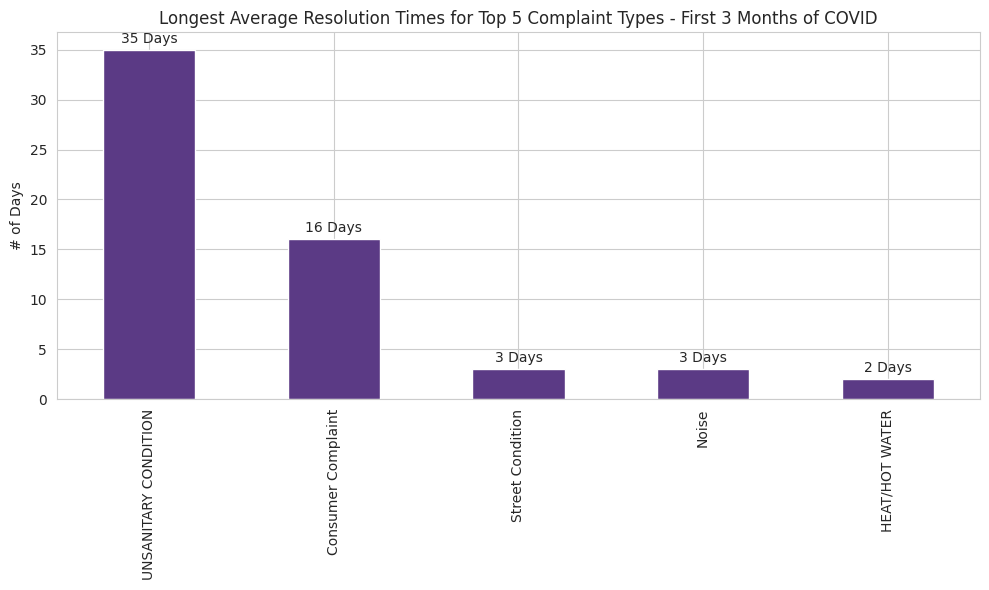

In [22]:
# Visualize
plt.figure(figsize=(10, 6))
ax = avg_resolution_days_top_5.plot(kind='bar', color = '#5B3A85')
ax.bar_label(ax.containers[0],fmt = '{:.0f} Days', padding = 3)
plt.title('Longest Average Resolution Times for Top 5 Complaint Types - First 3 Months of COVID')
plt.xlabel('')
plt.ylabel('# of Days')
plt.tight_layout()
plt.show()

**Finding:** Unsanitary condition and consumer complaint have markedly high average resolution times. Futher analysis must be completed to determine if the averages are being exaggerated by outliers.

### Analysis: Unsanitary Condition complaints averaging 35 days to complete

In [23]:
# Isolate Unsanitary Condition Complaints
unsanitary = df_top_over_10000[df_top_over_10000['complaint_type'] == 'UNSANITARY CONDITION']

# Converted to days
unsanitary_days = round(unsanitary['resolution_hours'] / 24)

# Distribution Stats
print(unsanitary_days.describe())

count      10410.0
mean     35.423439
std      42.284021
min            0.0
25%            7.0
50%           20.0
75%           51.0
max          362.0
Name: resolution_hours, dtype: Float64


In [24]:
# Extreme cases investigated

# Amount of unsanitary condition complaints resolved after 30 days
extreme = (unsanitary_days > 30).sum()
total = len(unsanitary_days)
pct = (extreme/total) * 100

# Descriptors for the 3 longest complaints
longest_complaints_to_resolve = unsanitary.groupby('descriptor')['resolution_hours'].mean().sort_values(ascending=False).head(3)
longest_complaints_to_resolve = round(longest_complaints_to_resolve / 24, 1)

print(f"Unsanitary Condition Complaints Resolved After 30 Days: {extreme} out of {total:,}")
print(f"{pct:.1f}% of all Unsanitary Condition Complaints took 30 days or more to resolve")
print(f"Longest Complaints to Resolve (Average Days):")
for descriptor, days in longest_complaints_to_resolve.items():
    print(f"{descriptor}: {days}")

Unsanitary Condition Complaints Resolved After 30 Days: 4105 out of 10,410
39.4% of all Unsanitary Condition Complaints took 30 days or more to resolve
Longest Complaints to Resolve (Average Days):
SEWAGE: 46.7
PESTS: 43.8
MOLD: 29.6


**Finding:** Though a majority of unsanitary condition complaints are resolved within 30 days, almost 40% of complaints still took at least 30 days to resolve. Sewage, pests, and mold were the three complaint descriptors driving delays.

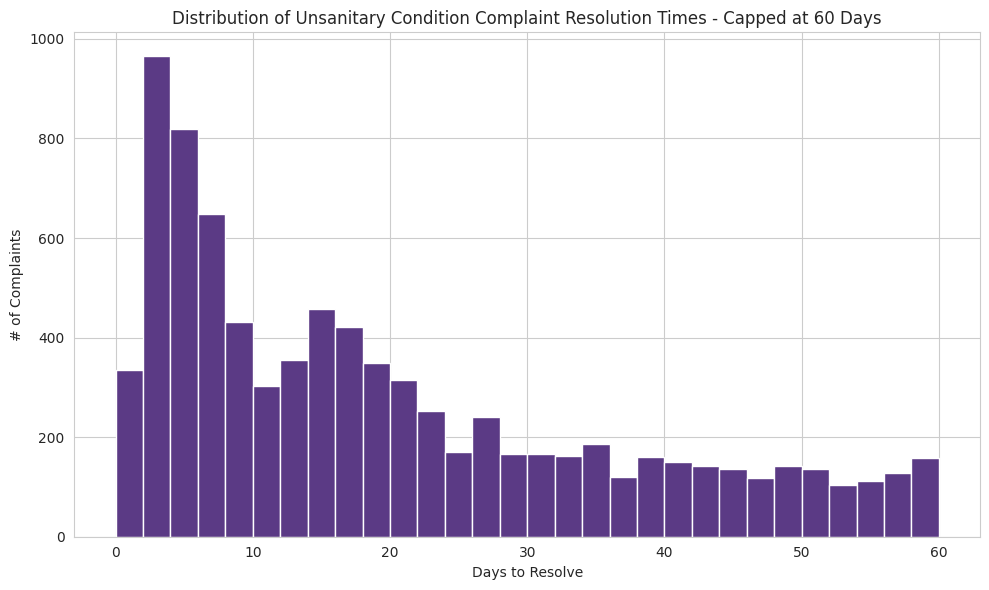

In [25]:
# Visualize Spread of Complaint Resolution Times (Histogram capped at 60 days)
plt.figure(figsize=(10, 6))
ax=unsanitary_days[unsanitary_days <= 60].plot(kind='hist', bins=30, color = '#5B3A85')
plt.title('Distribution of Unsanitary Condition Complaint Resolution Times - Capped at 60 Days')
plt.xlabel('Days to Resolve')
plt.ylabel('# of Complaints')
plt.tight_layout()
plt.show()

**Finding:** Unsanitary conditions for the most part seem to be resolved within the first 10 day - however a slowly tapering distribution suggests the average resolution times may not be exaggerated by a few outliers.

### Analysis: Consumer Complaints averaging 16 days to resolve

In [26]:
# Isolate Consumer Complaints
consumer = df_top_over_10000[df_top_over_10000['complaint_type'] == 'Consumer Complaint']

# Converted to days
consumer_days = round(consumer['resolution_hours'] / 24)

# Distribution Stats
print(consumer_days.describe())

count      20576.0
mean      15.75695
std      56.075222
min            0.0
25%            1.0
50%            2.0
75%            3.0
max          298.0
Name: resolution_hours, dtype: Float64


In [27]:
# Extreme cases investigated

# Amount of consumer complaints resolved after 16 days
extreme = (consumer_days > 16).sum()
total = len(consumer_days)
pct = (extreme/total) * 100

# Descriptors for the 3 longest complaints
longest_complaints_to_resolve = consumer.groupby('descriptor')['resolution_hours'].mean().sort_values(ascending=False).head(3)
longest_complaints_to_resolve = round(longest_complaints_to_resolve / 24, 1)

print(f"Consumer Complaints Resolved After 16 Days: {extreme} out of {total:,}")
print(f"{pct:.1f}% of all Consumer Complaints took 16 days or more to resolve")
print(f"Longest Complaints to Resolve (Average Days):")
for descriptor, days in longest_complaints_to_resolve.items():
    print(f"{descriptor}: {days}")

Consumer Complaints Resolved After 16 Days: 1188 out of 20,576
5.8% of all Consumer Complaints took 16 days or more to resolve
Longest Complaints to Resolve (Average Days):
Rental Hall: 209.9
Home Heating Oil Company: 197.1
Furniture Store: 192.7


**Finding:** Almost 95% of all consumer complaints were completed below the mean resolution time. The top three longest complaints being all over 190 days may be a key attributing factor to the inflated average.

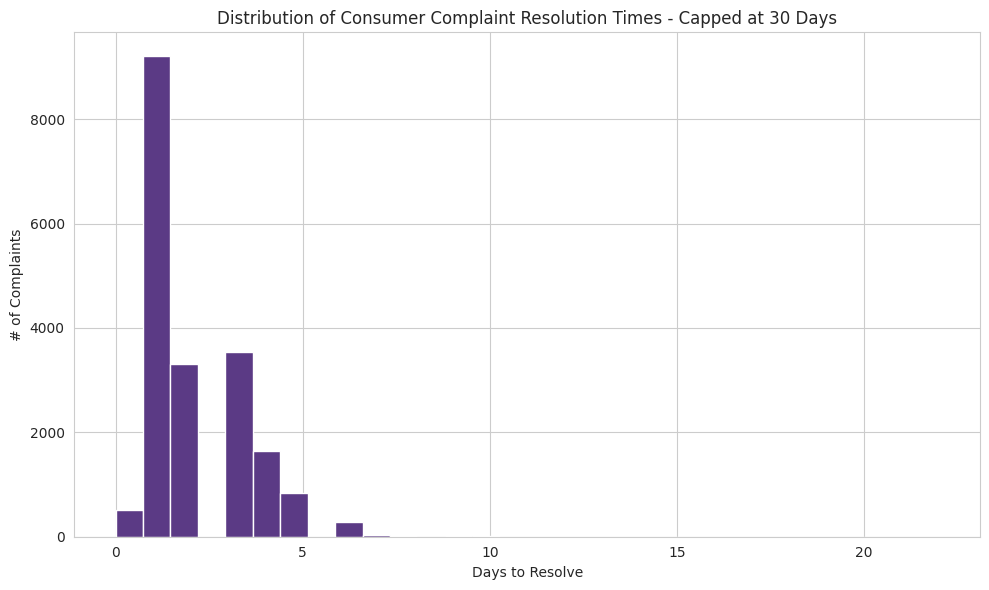

In [28]:
# Visualize Spread of Complaint Resolution Times (Histogram capped at 30 days)
plt.figure(figsize=(10, 6))
consumer_days[consumer_days <= 30].plot(kind='hist', bins=30, color = '#5B3A85')
plt.title('Distribution of Consumer Complaint Resolution Times - Capped at 30 Days')
plt.xlabel('Days to Resolve')
plt.ylabel('# of Complaints')
plt.tight_layout()
plt.show()

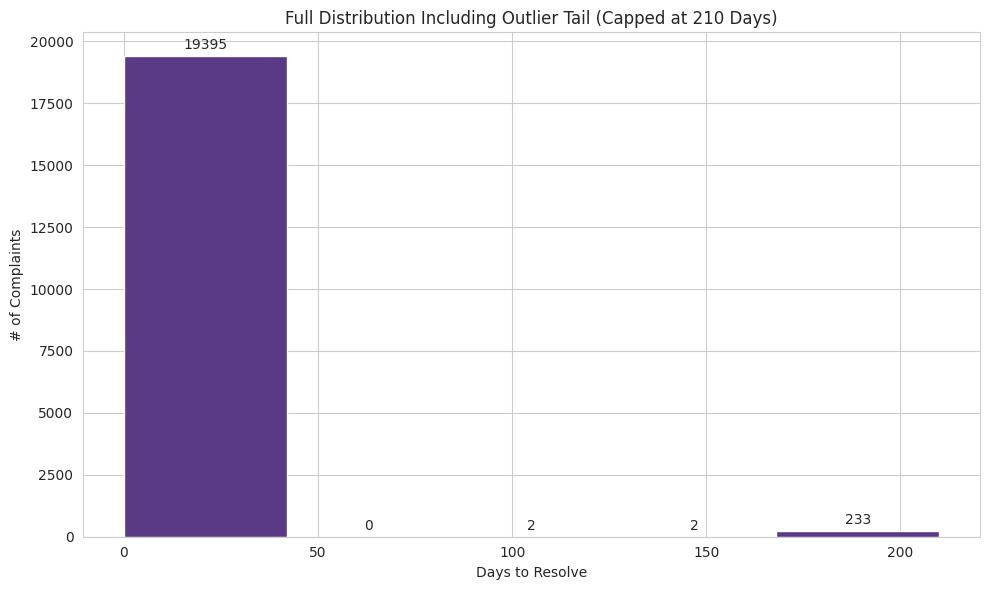

In [29]:
# Visualize Spread of Complaint Resolution Times (Histogram exaggerated to include possible skew)
plt.figure(figsize=(10, 6))
ax=consumer_days[consumer_days <= 210].plot(kind='hist', bins=5, color = '#5B3A85')
ax.bar_label(ax.containers[0],fmt = '{:.0f}', padding = 3)
plt.title('Full Distribution Including Outlier Tail (Capped at 210 Days)')
plt.xlabel('Days to Resolve')
plt.ylabel('# of Complaints')
plt.tight_layout()
plt.show()

**Finding:** A small number of consumer complaints that are over 200 days until resolved have skewed the average resolution hours. Median will most likely be a more accurate representation of the data for this complaint type.

### Outlier Skewing Investigation

In [30]:
# Comparing Mean vs Median to check for outlier skew
comparison = df_top_over_10000.groupby('complaint_type')['resolution_hours'].agg(['mean','median','count'])
comparison ['mean_days'] = round(comparison['mean'] / 24,1)
comparison ['median_days'] = round(comparison['median']/ 24,1)

# Show sorted by mean, highest first
print(comparison[['mean_days','median_days','count']].sort_values(by='mean_days', ascending=False))

                             mean_days  median_days  count
complaint_type                                            
UNSANITARY CONDITION              35.4         20.2  10410
Consumer Complaint                15.6          1.7  20576
Street Condition                   3.0          1.0  12259
Noise                              2.6          1.2  11222
HEAT/HOT WATER                     1.7          1.4  35577
Blocked Driveway                   0.1          0.0  16455
Illegal Parking                    0.1          0.0  31890
Noise - Residential                0.1          0.0  92074
Noise - Street/Sidewalk            0.0          0.0  31254
Non-Emergency Police Matter        0.0          0.0  57149
Noise - Vehicle                    0.0          0.0  14401


**Finding:** Outlier skew confirmed for consumer complaints - median will be more accurate to measure resolution times. Mean and median are closer for unsanitary condition - average resolution hours is more representative of the data here.

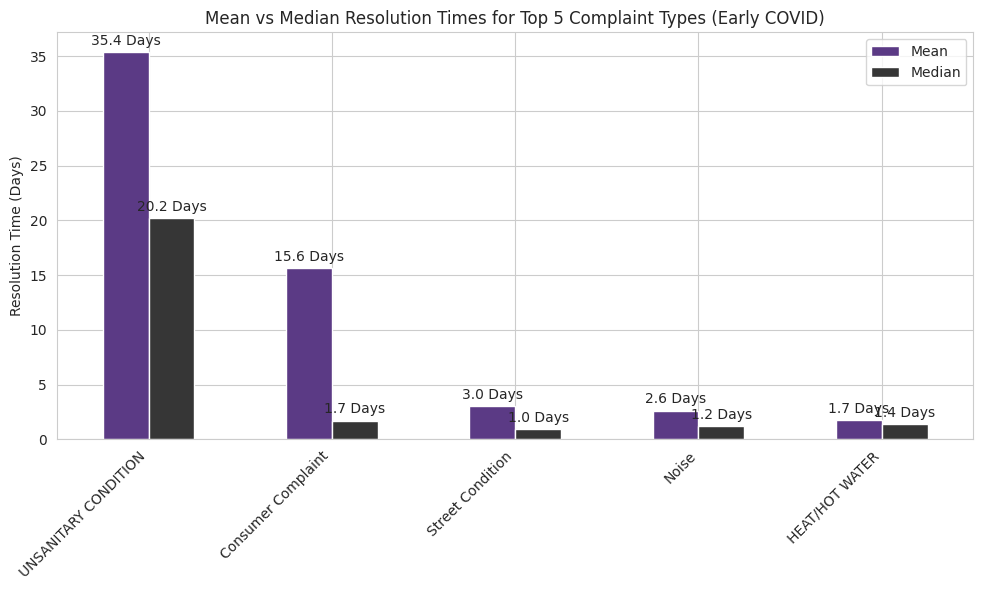

In [31]:
# Top complaints by mean with both metrics
comparison = ((df_top_over_10000.groupby('complaint_type')['resolution_hours'].agg(['mean','median'])) / 24).sort_values('mean', ascending=False).head(5)

# Grouped bar chart
ax = comparison.plot(kind='bar', color=['#5B3A85', '#363636'], figsize=(10,6))
ax.bar_label(ax.containers[0], fmt='{:.1f} Days', padding=3)
ax.bar_label(ax.containers[1], fmt='{:.1f} Days', padding=3)

plt.title("Mean vs Median Resolution Times for Top 5 Complaint Types (Early COVID)")
plt.xlabel("")
plt.ylabel("Resolution Time (Days)")
plt.legend(["Mean", "Median"])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Finding:** While unsanitary conditions complaints are closer in mean and median, consumer complaint has a vast discrepancy between the two and its median is closer to the next 3 highest volume complaint types medians. For further investigations mean vs median comparisons should be completed before finalizing on analysis to ensure outliers are being accounted for.

# Key Finding: Two Different Stories Behind Slow Resolution

Comparing mean and median resolution times reveals two distinct patterns:

**Unsanitary Conditions — Genuinely Slow**
With a median of 20 days (20.2), at least half of all unsanitary condition
complaints took 20+ days to resolve and almost 40% (39.4) at least 30 days to resolve. This reflects real, systemic
delay — likely driven by the need for in-person inspections and resolution that
were disrupted during early COVID lockdown.

**Consumer Complaints — Statistically Skewed**
Despite an almost 16-day average (15.6), the median was less than 2 days (1.7) — meaning
most consumer complaints resolved within two days. The high average
was driven by a small number of extreme outlier cases, not typical
performance (Top Three - Rental Hall: 209 Days, Home Heating Oil Company: 197 Days, Furniture Store: 192 Days). The Rental Hall delay outlier can also be expected when reviewing a time-series where social distancing started to increase.

**Analytical takeaway:** Relying on averages alone would have
mischaracterized consumer complaint performance as poor when it was
actually fast for most cases. This underscores the importance of
examining distribution, not just central tendency, when reporting
operational metrics.

## Caveats and Future Analysis

- Findings are correlative and not entirely causative - a pre-COVID baseline comparison would strengthen conclusions
- Analysis covers only the first 3 months; longer timeframes may show recovery patterns
- Outlier treatment (median vs mean) significantly affects the narrative and should be considered in any operational decisions and future analysis